# Investigação Estatística, Probabilística e Visual -- AB_NYC_2019

### Parte 1: Limpeza e Estruturação

---
### 0 Carregamento do dataset e importção das bibliotecas

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
import matplotlib.ticker as mticker
plt.style.use('ggplot')
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [60]:
#00.Carga de Dados -- Dataset
FILE_PATH = '/home/joao/Área de trabalho/New York City Airbnb Open Data/data/raw/AB_NYC_2019.csv'
df_raw = pd.read_csv(FILE_PATH, encoding='latin-1')

print(f'Dataset carregado: {df_raw.shape[0]} linhas x {df_raw.shape[1]} colunas')

Dataset carregado: 48895 linhas x 16 colunas


---
### 01​ Exploração Inicial

In [61]:
print('Visualização das Primeiras colunas: ')
df_raw.head()

Visualização das Primeiras colunas: 


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [62]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [63]:
print("Tipos das Coluna: ")
df_raw.dtypes

Tipos das Coluna: 


id                                  int64
name                                  str
host_id                             int64
host_name                             str
neighbourhood_group                   str
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                           str
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object

In [64]:
'''
Tipologia Para o Dataset AB_NYC_2019.csv:

id ->                               int64
name ->                             str
host_id ->                          int64
host_name ->                        str
neighbourhood_group ->              category  *ALTERAÇÃO
neighbourhood ->                    category  *ALTERAÇÃO
latitude ->                         float64
longitude ->                        float64
room_type ->                        category  *ALTERAÇÃO
price ->                            float64  *ALTERAÇÃO
minimum_nights ->                   int64
number_of_reviews ->                int64
last_review ->                      datetime64  *ALTERAÇÃO
reviews_per_month ->                float64
calculated_host_listings_count ->   int64
availability_365 ->                 int64

'''

'\nTipologia Para o Dataset AB_NYC_2019.csv:\n\nid ->                               int64\nname ->                             str\nhost_id ->                          int64\nhost_name ->                        str\nneighbourhood_group ->              category  *ALTERAÇÃO\nneighbourhood ->                    category  *ALTERAÇÃO\nlatitude ->                         float64\nlongitude ->                        float64\nroom_type ->                        category  *ALTERAÇÃO\nprice ->                            float64  *ALTERAÇÃO\nminimum_nights ->                   int64\nnumber_of_reviews ->                int64\nlast_review ->                      datetime64  *ALTERAÇÃO\nreviews_per_month ->                float64\ncalculated_host_listings_count ->   int64\navailability_365 ->                 int64\n\n'

In [65]:
print('Descrição Estatística das Colunas Float64: ')
df_raw[['latitude', 'longitude', 'price', 'reviews_per_month']].describe()

Descrição Estatística das Colunas Float64: 


,latitude,longitude,price,reviews_per_month
count,48895.000000,48895.000000,48895.000000,38843.000000
mean,40.728949,-73.952170,152.720687,1.373221
std,0.054530,0.046157,240.154170,1.680442
min,40.499790,-74.244420,0.000000,0.010000
25%,40.690100,-73.983070,69.000000,0.190000
50%,40.723070,-73.955680,106.000000,0.720000
75%,40.763115,-73.936275,175.000000,2.020000
max,40.913060,-73.712990,10000.000000,58.500000


In [66]:
print('Identificação de Valores Nulos: ')
df_raw.isnull().sum()

Identificação de Valores Nulos: 


id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [67]:
print("Identificação de Duplicatas: ")
print(df_raw.duplicated().sum())

Identificação de Duplicatas: 
0


---
### 02 Tratamento dos Dados  
**Tramento de Nulos**  
**Alteração Tipologia**  


In [68]:
#Copia do Dataset para Manipulação
df = df_raw.copy()
print('Cópia realizada!', df.shape)

Cópia realizada! (48895, 16)


In [69]:
# Mundança de Tipologia 

#Categoty:
df['room_type'] = df['room_type'].astype('category')
df['neighbourhood_group'] = df['neighbourhood_group'].astype('category')
df['neighbourhood'] = df['neighbourhood'].astype('category')

#Datetime64:
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

#float64
df['price'] = df['price'].astype('float64')

print('Tipos de dados após a mudança:\n')
print(df.dtypes[['room_type', 'neighbourhood_group', 'neighbourhood', 'price', 'last_review']])

print('\nTipos do dataframe após a mudança:')
df.dtypes

Tipos de dados após a mudança:

room_type                    category
neighbourhood_group          category
neighbourhood                category
price                         float64
last_review            datetime64[us]
dtype: object

Tipos do dataframe após a mudança:


id                                         int64
name                                         str
host_id                                    int64
host_name                                    str
neighbourhood_group                     category
neighbourhood                           category
latitude                                 float64
longitude                                float64
room_type                               category
price                                    float64
minimum_nights                             int64
number_of_reviews                          int64
last_review                       datetime64[us]
reviews_per_month                        float64
calculated_host_listings_count             int64
availability_365                           int64
dtype: object

In [70]:
#Tratamento das Colunas com valores nulos
#Colunas com nulas:
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
df = df.dropna(subset=['name', 'host_name'])

print('Colunas com valores nulos atualizadas:')
df.isnull().sum()

Colunas com valores nulos atualizadas:


id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10037
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [71]:
#Verficação dos Valores Únicos nas Colunas Categóricas (para encontrar possíveis erros de digitação ou inconsistências)
print("Valores únicos em room_type: ")
print(df['room_type'].value_counts())

print("\nValores únicos em neighbourhood_group: ")
print(df['neighbourhood_group'].value_counts())


Valores únicos em room_type: 
room_type
Entire home/apt    25393
Private room       22306
Shared room         1159
Name: count, dtype: int64

Valores únicos em neighbourhood_group: 
neighbourhood_group
Manhattan        21643
Brooklyn         20089
Queens            5664
Bronx             1089
Staten Island      373
Name: count, dtype: int64


In [72]:
#Verificação de possíveis erros de digitação ou inconsistências na coluna 'neighbourhood'
# Já que são muitos...
qtd_bairros_antes = df['neighbourhood'].nunique()

df['neighbourhood'] = df['neighbourhood'].str.strip().astype('category')

qtd_bairros_depois = df['neighbourhood'].nunique()

print(f"Quantidade de bairros únicos ANTES do strip: {qtd_bairros_antes}")
print(f"Quantidade de bairros únicos DEPOIS do strip: {qtd_bairros_depois}")

if qtd_bairros_antes == qtd_bairros_depois:
    print("Tudo certo! Não havia bairros duplicados por conta de espaços.")
else:
    print("Havia erros de digitação (espaços extras) que agora foram corrigidos!")


Quantidade de bairros únicos ANTES do strip: 221
Quantidade de bairros únicos DEPOIS do strip: 221
Tudo certo! Não havia bairros duplicados por conta de espaços.


---
### 03 Identificação e Tratamento de Outliers

In [73]:
def contar_outliers(series):
    if not pd.api.types.is_numeric_dtype(series):
        return 0
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    return ((series < limite_inferior) | (series > limite_superior)).sum()

In [74]:
outliers_por_coluna = df.select_dtypes(include=[np.number]).apply(contar_outliers)
print("Quantidade de Outliers por Coluna:")
print(outliers_por_coluna)

Quantidade de Outliers por Coluna:
id                                   0
host_id                           1525
latitude                           425
longitude                         2832
price                             2971
minimum_nights                    6605
number_of_reviews                 6015
reviews_per_month                 3309
calculated_host_listings_count    7080
availability_365                     0
dtype: int64


In [75]:
'''' OBS 02
As colunas 'host_id', 'latitude' e 'longitude' são colunas que não precisam
do tratamento de outliers, por conta do CONTEXTO

Já as colunas 'price', 'minimun_nights', 'number_of_reviews', 'reviews_per_month',
e 'calculated_host_listings_count' precisam de acordo com o CONTEXTO
'''

"' OBS 02\nAs colunas 'host_id', 'latitude' e 'longitude' são colunas que não precisam\ndo tratamento de outliers, por conta do CONTEXTO\n\nJá as colunas 'price', 'minimun_nights', 'number_of_reviews', 'reviews_per_month',\ne 'calculated_host_listings_count' precisam de acordo com o CONTEXTO\n"

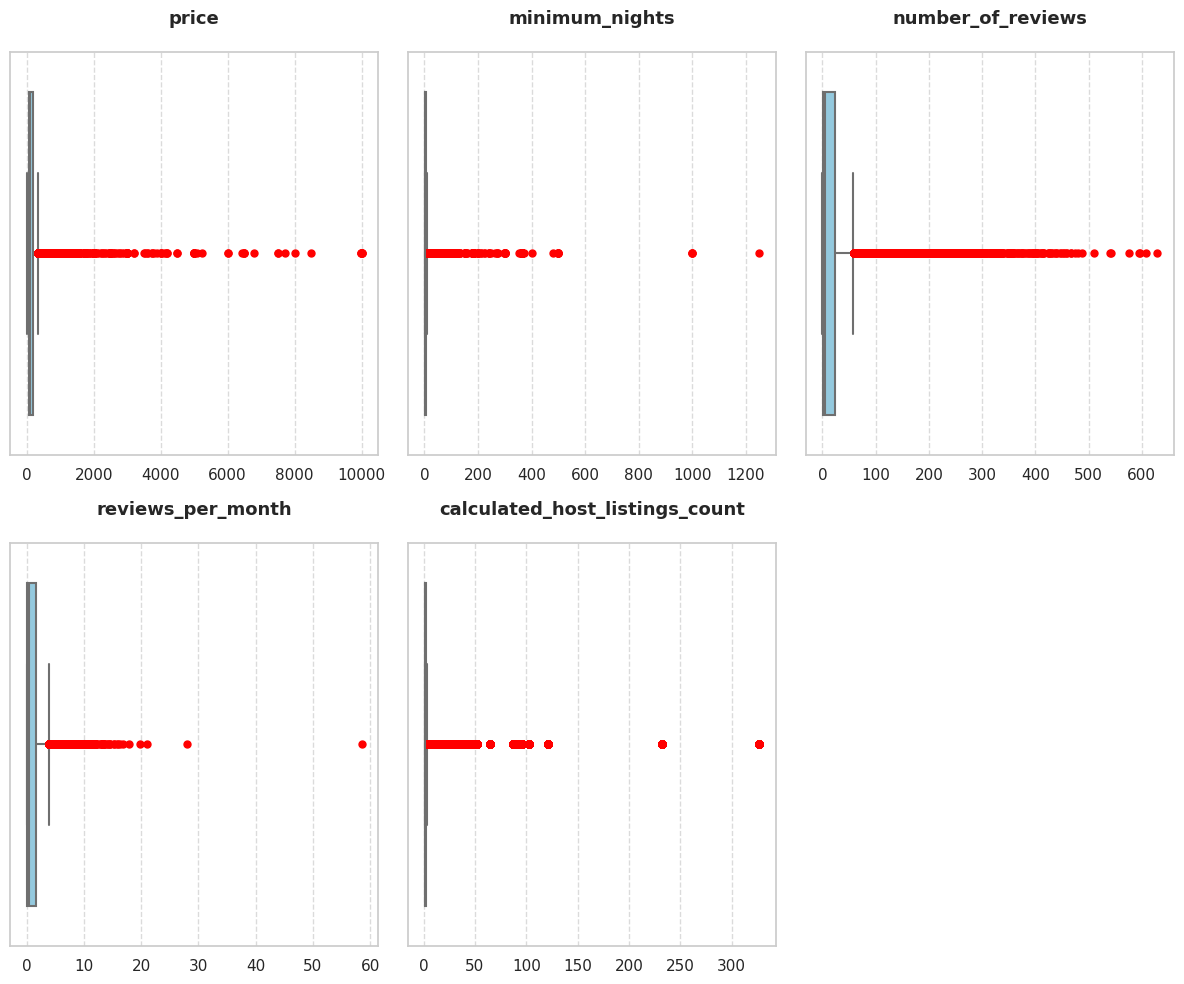

In [76]:
#Visualização do Outliers
fig, axes = plt.subplots(2, 3, figsize=(12, 10))
cols = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count']

axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(
        data=df,
        x=col,
        ax=axes[i],
        color='skyblue',
        linewidth=1.5,
        flierprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "red", "markersize": 5}
    )
    axes[i].set_title(col, fontsize=13, fontweight='bold',pad=20)
    axes[i].set_xlabel('')
    axes[i].xaxis.grid(True, linestyle='--', alpha=0.7)

for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

---
### 3.1 Analise Profunda os Outliers e dos Quartis (SEGUNDO O CONTEXTO)

 - As colunas:price / minimum_nights / number_of_reviews / reviews_per_month /calculated_host_listings_count 
 - Foram analisadas de forma detalhada levando em consideração o contexto 


In [77]:
df[['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count']].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.95, 0.99])
# FOI ADICIONADO OS PERCENTIS 0.1, 0.95 E 0.99 PARA MELHOR VISUALIZAÇÃO DE ALGUM PROBLEMA DE INPUTS ERRADOS

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count
count,48858.000000,48858.000000,48858.000000,48858.000000,48858.000000
mean,152.740309,7.012444,23.273098,1.091124,7.148369
std,240.232386,20.019757,44.549898,1.597270,32.964600
min,0.000000,1.000000,0.000000,0.000000,1.000000
10%,49.000000,1.000000,0.000000,0.000000,1.000000
25%,69.000000,1.000000,1.000000,0.040000,1.000000
50%,106.000000,3.000000,5.000000,0.370000,1.000000
75%,175.000000,5.000000,24.000000,1.580000,2.000000
95%,355.000000,30.000000,114.000000,4.310000,15.000000
99%,799.000000,45.000000,214.000000,6.800000,232.000000


In [78]:
'''price:'''
df = df[df['price'] > 0]
print(f"Registros restantes após remover preços zerados: {len(df)}")

Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

limite_superior_price = Q3 + 1.5 * IQR

df = df[df['price'] <= limite_superior_price]

print(f"\nLimite superior calculado: ${limite_superior_price:.2f}")
print(f"Registros restantes após remover outliers de preço: {len(df)}")

print("\nMédia de preço ANTES: $152.74")
print(f"Média de preço DEPOIS: ${df['price'].mean():.2f}")

print(f"\nNova descrição estatistica 'price':\n ", df['price'].describe())

Registros restantes após remover preços zerados: 48847

Limite superior calculado: $334.00
Registros restantes após remover outliers de preço: 45876

Média de preço ANTES: $152.74
Média de preço DEPOIS: $120.00

Nova descrição estatistica 'price':
  count    45876.000000
mean       119.999673
std         68.128278
min         10.000000
25%         65.000000
50%        100.000000
75%        159.000000
max        334.000000
Name: price, dtype: float64


In [79]:
'''minimum_nights: '''
#Em Nova York, existem leis rígidas de aluguel que muitas vezes obrigam os anfitriões a 
# alugar por no mínimo 30 dias. Então, ter 30 no minimum_nights é perfeitamente normal.
#LEI DE 2023 >>> ((Lei Local 18, ou Short-Term Rental Registration Law))
df_filtro = df[df['minimum_nights'] > 365]
df_filtro['minimum_nights'].value_counts()

df = df[df['minimum_nights'] <= 365]
print(f"Registros restantes após remover outliers de minimum_nights: {len(df)}")

print(f"\nNova descrição estatistica 'minimum_nights':\n ", df['minimum_nights'].describe())


Registros restantes após remover outliers de minimum_nights: 45863

Nova descrição estatistica 'minimum_nights':
  count    45863.000000
mean         6.760504
std         16.007794
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max        365.000000
Name: minimum_nights, dtype: float64


In [80]:
'''number_of_reviews'''
print('Valor maximo da coluna:',df['number_of_reviews'].max())

# DECISÃO: Deixar os outliers Cortar esses dados seria apagar os
# "melhores" e mais consolidados anúncios da plataforma

# OBS: Mesmo assim pode ter dados com inputs errados? Sim mas na logica o valore maximo
# é totalmente aceitavel para um "Limite Teórico" pq se o Airbnb existe desde 2008 então
# está dentro da quantidade logica de 18 anos

Valor maximo da coluna: 629


In [81]:
'''reviews_per_month'''
print('Quantidade de reviews ou erros de input tem acima de 15: ',len(df_raw[df_raw['reviews_per_month'] > 15]))

#Esse limite contextual é por conta de um "Limite Teórico" 
# (exigiria 1 check-in/check-out a cada 2 dias sem parar, com 100% de ocupação e 100% de taxa de avaliação)

#DECISÃO: Remover as 11 linhas acima do limite contextual, ate pq 11 para 45863 não impacta em muita coisa
df = df[df['reviews_per_month'] <= 15]
print("\nNova descrição estatistica 'reviews_per_month':\n ",df['reviews_per_month'].describe())

Quantidade de reviews ou erros de input tem acima de 15:  11

Nova descrição estatistica 'reviews_per_month':
  count    45852.000000
mean         1.103135
std          1.569391
min          0.000000
25%          0.050000
50%          0.380000
75%          1.620000
max         14.620000
Name: reviews_per_month, dtype: float64


In [82]:
'''calculated_host_listings_count'''
print('Valor maximo da coluna:',df['calculated_host_listings_count'].max())

# DECISÃO: Deixa os outliers, novamente por conta de contexto o host com maior numero de imóveis é
# 327 pode parecer estranho mas é bem aceitavel
# CONTEXTO: Uma pesquisa rápida descobri que: "No Airbnb de 2019, existiam megaempresas de gestão 
# de propriedades (property management companies, como Sonder, Blueground, etc.) que operavam centenas 
# de apartamentos na cidade usando um único perfil de "Host"."

Valor maximo da coluna: 327


---
### Exportação do Dataset Tratado

In [83]:
from datetime import date
from pathlib import Path

AUTORIZAR_EXPORTACAO = True
if AUTORIZAR_EXPORTACAO:
    hoje = date.today().strftime('%Y%m%d')
    OUTPUT_DIR = Path('/home/joao/Área de trabalho/New York City Airbnb Open Data/data/data_tratado_01')
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    OUTPUT_FILE = OUTPUT_DIR / f'AB_NYC_2019_{hoje}.csv'

    df.to_csv(OUTPUT_FILE, index=False, encoding='utf-8-sig')

    print(f'✅ Exportado: {OUTPUT_FILE}')
    print(f'   {df.shape[0]} linhas × {df.shape[1]} colunas')
else:
    print('Exportação não autorizada. Nenhum CSV tratado foi gerado.')

✅ Exportado: /home/joao/Área de trabalho/New York City Airbnb Open Data/data/data_tratado_01/AB_NYC_2019_20260416.csv
   45852 linhas × 16 colunas
